## Data Configuration

In [5]:
# ============================================
# DATA CONFIGURATION - Change mode here
# ============================================
MODE = 'TEST'  # Options: 'TRAIN' or 'TEST'

# Training data: All 2021 quarters
TRAIN_FILES = [
    '../data/raw/2021_Jan-Mar.csv',
    '../data/raw/2021_Aprl-Jun.csv',
    '../data/raw/2021_Jul-Sep.csv',
]

# Test data: 2022 Oct-Dec
TEST_FILES = [
    '../data/raw/2021_Oct-Dec.csv'
]

print(f"🔧 MODE: {MODE}")
print(f"📁 Files: {len(TRAIN_FILES if MODE == 'TRAIN' else TEST_FILES)} file(s)")

🔧 MODE: TEST
📁 Files: 1 file(s)


## Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load Data

In [7]:
column_names = [
    'Procuring Entity (PE)', 'Region', 'Province', 'City/Municipality', 
    'Government Branch', 'PE Organization Type', 'PE Organization Type (Grouped)', 
    'Bid Reference No.', 'Notice Title', 'Classification', 'Procurement Mode', 
    'Business Category', 'Funding Source', 'Funding Instrument', 'Trade Agreement', 
    'Approved Budget of the Contract', 'Published Date', 'Closing Date', 
    'Area of Delivery', 'Contract Duration', 'Calendar Type', 'Line Item No', 
    'Item Name', 'Item Description', 'Quantity', 'UOM', 'Item Budget', 
    'Bid Notice Status', 'Award Reference No.', 'Award Title', 'UNSPSC Code', 
    'UNSPSC Description', 'Published Date(Award)', 'Award Date', 'Contract Amount', 
    'Award Notice Status', 'Notice to Proceed Date', 'Contract Effectivity Date', 
    'Contract End Date', 'Awardee Organization Name', 'Country of Awardee', 
    'Region of Awardee', 'Province of Awardee', 'City/Municipality of Awardee', 
    'Awardee Size', 'Awardee Joint Venture'
]

# Load data based on MODE
files = TRAIN_FILES if MODE == 'TRAIN' else TEST_FILES
dfs = []

for file in files:
    df_temp = pd.read_csv(
        file,
        names=column_names,
        parse_dates=['Published Date', 'Closing Date', 'Award Date']
    )
    dfs.append(df_temp)
    print(f"  ✓ {Path(file).name}: {len(df_temp):,} rows")

df = pd.concat(dfs, ignore_index=True)

print(f"\n📊 Total: {len(df):,} rows × {len(df.columns)} columns")
print(f"🗓️  Period: {MODE} data")

/tmp/ipykernel_6493/364939860.py:22: DtypeWarning: Columns (0: Item Name, 1: Item Description, 2: UOM, 3: Award Title, 4: UNSPSC Description, 5: Published Date(Award), 6: Award Notice Status, 7: Notice to Proceed Date, 8: Contract Effectivity Date, 9: Contract End Date, 10: Awardee Organization Name, 11: Country of Awardee, 12: Region of Awardee, 13: Province of Awardee, 14: City/Municipality of Awardee, 15: Awardee Size, 16: Awardee Joint Venture) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(
/tmp/ipykernel_6493/364939860.py:22: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_temp = pd.read_csv(
/tmp/ipykernel_6493/364939860.py:22: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_temp = pd.read_csv(


  ✓ 2021_Oct-Dec.csv: 501,645 rows

📊 Total: 501,645 rows × 46 columns
🗓️  Period: TEST data


In [8]:
# First few rows
df.head()

,Procuring Entity (PE),Region,Province,City/Municipality,Government Branch,PE Organization Type,PE Organization Type (Grouped),Bid Reference No.,Notice Title,Classification,Procurement Mode,Business Category,Funding Source,Funding Instrument,Trade Agreement,Approved Budget of the Contract,Published Date,Closing Date,Area of Delivery,Contract Duration,Calendar Type,Line Item No,Item Name,Item Description,Quantity,UOM,Item Budget,Bid Notice Status,Award Reference No.,Award Title,UNSPSC Code,UNSPSC Description,Published Date(Award),Award Date,Contract Amount,Award Notice Status,Notice to Proceed Date,Contract Effectivity Date,Contract End Date,Awardee Organization Name,Country of Awardee,Region of Awardee,Province of Awardee,City/Municipality of Awardee,Awardee Size,Awardee Joint Venture
0,CONSTRUCTION INDUSTRY AUTHORITY OF THE PHILIPP...,NCR,Metro Manila,Makati City,Executive,Attached Agency,National Government Agencies (NGA),0,Procurement of Photocopier Consumables for Off...,Goods,Direct Contracting (Sec. 50),Printing Supplies,Government of the Philippines (GOP),General Appropriations Act,Implementing Rules and Regulations,64575.00,02/10/2024,NaT,Metro Manila,15.0,NaN,1.0,Procurement of Photocopier Consumables for Off...,Procurement of Photocopier Consumables for Off...,1.0,Lot,64575.00,Awarded,5103217.0,Procurement of Photocopier Consumables for Off...,45000000.0,Printing and Photographic and Audio and Visual...,02/10/2024,2024-09-16,64575.00,Updated,20/09/2024,20/09/2024,30/09/2024,"PHILIPPINE DUPLICATORS, INC.",Philippines,NCR,Metro Manila,Parañaque City,NaN,NaN
1,AGRICULTURAL TRAINING INSTITUTE,NCR,Metro Manila,Quezon City,Executive,Attached Agency,National Government Agencies (NGA),0,Provision of venue for the conduct of 17th Nat...,Goods - General Support Services,Negotiated Procurement - Agency to Agency (Sec...,Hotel and Lodging and Meeting Facilities,Government of the Philippines (GOP),General Appropriations Act,Implementing Rules and Regulations,80000.00,NaN,NaT,Albay,2.0,NaN,1.0,Venue,Provision of venue for the conduct of 17th Nat...,1.0,Lot,80000.00,Awarded,4918650.0,Provision of venue for the conduct of 17th Nat...,90111600.0,Meeting facilities,07/11/2024,2024-10-21,80000.00,Updated,21/10/2024,23/10/2024,24/10/2024,"CITY OF LEGAZPI, ALBAY",Philippines,Region V,Albay,Legazpi City,NaN,NaN
2,DEPARTMENT OF EDUCATION - REGION IV-A (CALABAR...,Region IV-A,Rizal,Cainta,Executive,Attached Agency,National Government Agencies (NGA),0,Lease of Venue with Food and Accommodation - T...,Goods,Negotiated Procurement - Lease of Real Propert...,Lease and Rental of Property or Building,Government of the Philippines (GOP),General Appropriations Act,Implementing Rules and Regulations,3840000.00,NaN,NaT,NaN,15.0,NaN,1.0,Lease of Venue with Food and Accommodation - T...,Lease of Venue with Food and Accommodation - T...,1.0,Lump Sum,3840000.00,Awarded,4973761.0,Lease of Venue with Food and Accommodation - T...,80131500.0,Lease and rental of property or building,10/10/2024,2024-09-25,3840000.00,Updated,01/10/2024,01/10/2024,30/10/2024,"THE FIRST VILLA CRISTINA HOTEL & RESORT, INC.",Philippines,Region IV-A,Rizal,Antipolo City,Medium,NaN
3,"CITY OF BATAC, ILOCOS NORTE",Region I,Ilocos Norte,Batac,Executive,City Government,Local Government Units (LGU),0,PURCHASE OF PHOTOCOPIER CONSUMABLES OF DIFFERE...,Goods,Direct Contracting (Sec. 50),Office Equipment Supplies and Consumables,Government of the Philippines (GOP),Budget for the Contract Approved by the Sanggu...,Implementing Rules and Regulations,152100.00,25/10/2024,NaT,Ilocos Norte,7.0,NaN,1.0,PHOTOCOPIER CONSUMABLES,VARIOUS TONER & DRUM,1.0,Lot,152100.00,Awarded,4981764.0,PURCHASE OF PHOTOCOPIER CONSUMABLES OF DIFFERE...,44101700.0,Printer and photocopier and facsimile accessories,25/10/2024,2023-11-08,145932.88,Posted,NaN,NaN,NaN,"PHILIPPINE DUPLICATORS, INC.",Philippines,NCR,Metro Manila,Parañaque City,NaN,NaN
4,CITY OF QUEZON,NCR,Metro Manila,Quezon City,Executive,City Government,Loca

In [9]:
# Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 501645 entries, 0 to 501644
Data columns (total 46 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Procuring Entity (PE)            501645 non-null  str           
 1   Region                           501645 non-null  str           
 2   Province                         501645 non-null  str           
 3   City/Municipality                501645 non-null  str           
 4   Government Branch                501645 non-null  str           
 5   PE Organization Type             501645 non-null  str           
 6   PE Organization Type (Grouped)   501645 non-null  str           
 7   Bid Reference No.                501645 non-null  int64         
 8   Notice Title                     501645 non-null  str           
 9   Classification                   501645 non-null  str           
 10  Procurement Mode                 501645 non-null  str  

## 1.5. Data Quality Filter

In [22]:
print("=== DATA QUALITY FILTER (VECTORIZED - FAST!) ===\n")

# SAVE ORIGINAL COUNT FIRST (before any modifications)
original_row_count = len(df)
print(f"Raw rows loaded: {original_row_count:,}")

# Convert dates (already done in load, but ensure proper handling)
df['Published Date'] = pd.to_datetime(df['Published Date'], errors='coerce')
df['Closing Date'] = pd.to_datetime(df['Closing Date'], errors='coerce')
df['Award Date'] = pd.to_datetime(df['Award Date'], errors='coerce')

# Convert financial columns to numeric
df['Approved Budget of the Contract'] = pd.to_numeric(df['Approved Budget of the Contract'], errors='coerce')
df['Contract Amount'] = pd.to_numeric(df['Contract Amount'], errors='coerce')

# === QUALITY CHECKS (VECTORIZED) ===

# 1. Valid financial data (not NaN, not negative)
valid_finance = (
    df['Approved Budget of the Contract'].notna() & 
    df['Contract Amount'].notna() &
    (df['Approved Budget of the Contract'] >= 0) &
    (df['Contract Amount'] >= 0)
)
print(f"✓ Valid financial data: {valid_finance.sum():,} rows")

# 2. Valid date sequence: Published <= Closing
valid_dates = (
    df['Published Date'].notna() &
    df['Closing Date'].notna() &
    (df['Published Date'] <= df['Closing Date'])
)
print(f"✓ Valid date sequence (Published <= Closing): {valid_dates.sum():,} rows")

# 3. Valid award timing (if Award Date exists)
valid_award = (
    (df['Award Date'].isna()) |  # Award date can be missing
    ((df['Award Date'].notna()) & (df['Closing Date'] <= df['Award Date']))
)
print(f"✓ Valid award timing (Closing <= Award or null): {valid_award.sum():,} rows")

# Combine all filters
df_clean = df[valid_finance & valid_dates & valid_award].copy()

# Calculate actual drops
dropped_count = original_row_count - len(df_clean)
dropped_pct = (dropped_count / original_row_count * 100)

print(f"\n=== FINAL CLEAN DATASET ===")
print(f"Clean rows: {len(df_clean):,}")
print(f"Dropped: {dropped_count:,} corrupted/spilled rows ({dropped_pct:.1f}%)")

# Show breakdown of what was dropped
print(f"\nDropped breakdown:")
print(f"  Invalid finance: {(~valid_finance).sum():,}")
print(f"  Invalid date sequence: {(~valid_dates).sum():,}")
print(f"  Invalid award timing: {(~valid_award).sum():,}")

# Replace original df with clean version
df = df_clean
print(f"\n✅ Using clean dataset for all further analysis: {len(df):,} rows")

=== DATA QUALITY FILTER (VECTORIZED - FAST!) ===

Raw rows loaded: 89,104
✓ Valid financial data: 89,104 rows
✓ Valid date sequence (Published <= Closing): 89,104 rows
✓ Valid award timing (Closing <= Award or null): 89,104 rows

=== FINAL CLEAN DATASET ===
Clean rows: 89,104
Dropped: 0 corrupted/spilled rows (0.0%)

Dropped breakdown:
  Invalid finance: 0
  Invalid date sequence: 0
  Invalid award timing: 0

✅ Using clean dataset for all further analysis: 89,104 rows


## 2. Data Quality Check

In [23]:
# Missing values in key columns
key_cols = [
    'Procurement Mode', 'Funding Instrument', 'Awardee Organization Name',
    'UNSPSC Code', 'Contract Amount', 'Approved Budget of the Contract',
    'Published Date', 'Closing Date', 'Award Date'
]

missing = pd.DataFrame({
    'Column': key_cols,
    'Missing': [df[col].isnull().sum() for col in key_cols],
    'Percent': [(df[col].isnull().sum() / len(df) * 100).round(1) for col in key_cols]
})

print("Missing values in KEY columns:")
print(missing)

Missing values in KEY columns:
                            Column  Missing  Percent
0                 Procurement Mode        0      0.0
1               Funding Instrument        0      0.0
2        Awardee Organization Name        0      0.0
3                      UNSPSC Code       75      0.1
4                  Contract Amount        0      0.0
5  Approved Budget of the Contract        0      0.0
6                   Published Date        0      0.0
7                     Closing Date        0      0.0
8                       Award Date        0      0.0


In [24]:
# Check duplicates (same bid, multiple items)
bid_duplicates = df['Bid Reference No.'].value_counts()
print(f"Unique bids: {df['Bid Reference No.'].nunique():,}")
print(f"Total rows: {len(df):,}")
print(f"Bids with multiple items: {(bid_duplicates > 1).sum():,}")
print("\n⚠️ Will deduplicate to contract-level in preprocessing")

Unique bids: 47,404
Total rows: 89,104
Bids with multiple items: 7,518

⚠️ Will deduplicate to contract-level in preprocessing


## 3. Explore KEY Columns

In [13]:
# ⭐⭐⭐ Procurement Mode (competitive vs negotiated)
print("PROCUREMENT MODE:")
print(df['Procurement Mode'].value_counts().head(10))

PROCUREMENT MODE:
Procurement Mode
Public Bidding                                                           40509
Negotiated Procurement - Small Value Procurement (Sec. 53.9)             39394
Shopping - Ordinary/Regular Office Supplies & Equipment (Sec. 52.1.b)     8163
Negotiated Procurement - Two Failed Biddings (Sec. 53.1)                   821
Negotiated Procurement - Community Participation (Sec. 53.12)              173
Negotiated Procurement - NGO Participation (Sec. 53.11)                     23
International Competitive Bidding                                           17
Limited Source Bidding (Sec. 49)                                             4
Name: count, dtype: int64


In [14]:
# ⭐⭐⭐ Funding Instrument (national vs corporate vs local)
print("FUNDING INSTRUMENT:")
print(df['Funding Instrument'].value_counts())

FUNDING INSTRUMENT:
Funding Instrument
General Appropriations Act                                                 47996
Budget for the Contract Approved by the Sanggunian                         28180
Corporate Budget for the Contract Approved by the Board                     7419
National Expenditure Program (NEP) for the suceeding year - Single Year     4887
Loans / Grants                                                               571
National Expenditure Program (NEP) for the succeeding year - Multi-year       51
Name: count, dtype: int64


In [15]:
# ⭐⭐⭐ Awardee concentration
print("TOP 10 AWARDEES (by frequency):")
print(df['Awardee Organization Name'].value_counts().head(10))

TOP 10 AWARDEES (by frequency):
Awardee Organization Name
ENDURE MEDICAL, INC.                        1970
BEROVAN MARKETING, INC.                      787
MEDICAL CENTER TRADING CORPORATION           529
DOÑA ALEJANDRA, INCORPORATED                 486
TACLOBAN TAP COMMERCIAL, INC.                476
SCHEIRMAN CONSTRUCTION CONSOLIDATED INC.     312
METRO DRUG, INC.                             290
GOLDEN TILLER CONSTRUCTION AND SUPPLY        259
PHIL PHARMAWEALTH, INC.                      256
M.A.N. CONSTRUCTION SUPPLY & SERVICES        248
Name: count, dtype: int64


In [16]:
# ⭐⭐ UNSPSC Code (what's being bought)
print("TOP 10 UNSPSC CODES:")
top_codes = df['UNSPSC Code'].value_counts().head(10)
print(top_codes)

print("\nWith descriptions:")
# Get the top 10 most frequent codes and their descriptions
for code in top_codes.index:
    desc = df[df['UNSPSC Code'] == code]['UNSPSC Description'].iloc[0]
    print(f"{code}: {desc}")

TOP 10 UNSPSC CODES:
UNSPSC Code
44000000.0    7803
42000000.0    6708
72000000.0    6547
51000000.0    4514
90101603.0    2885
44120000.0    2843
30000000.0    2579
50000000.0    2220
41000000.0    1599
43000000.0    1343
Name: count, dtype: int64

With descriptions:
44000000.0: Office Equipment and Accessories and Supplies
42000000.0: Medical Equipment and Accessories and Supplies
72000000.0: Building and Facility Construction and Maintenance Services
51000000.0: Drugs and Pharmaceutical Products
90101603.0: Catering services
44120000.0: Office supplies
30000000.0: Structures and Building and Construction and Manufacturing Components and Supplies
50000000.0: Food Beverage and Tobacco Products
41000000.0: Laboratory and Measuring and Observing and Testing Equipment
43000000.0: Information Technology Broadcasting and Telecommunications


In [17]:
# ⭐⭐ Contract Amount & Approved Budget
print("CONTRACT AMOUNT (PHP):")
stats = df['Contract Amount'].describe()
for stat, value in stats.items():
    if stat == 'count':
        print(f"  {stat:8s}: {value:,.0f}")
    else:
        print(f"  {stat:8s}: ₱{value:,.2f}")

print("\nAPPROVED BUDGET (PHP):")
stats = df['Approved Budget of the Contract'].describe()
for stat, value in stats.items():
    if stat == 'count':
        print(f"  {stat:8s}: {value:,.0f}")
    else:
        print(f"  {stat:8s}: ₱{value:,.2f}")

CONTRACT AMOUNT (PHP):
  count   : 89,104
  mean    : ₱7,070,440.40
  std     : ₱115,814,004.23
  min     : ₱0.00
  25%     : ₱58,552.25
  50%     : ₱176,100.00
  75%     : ₱951,858.02
  max     : ₱26,824,265,989.00

APPROVED BUDGET (PHP):
  count   : 89,104
  mean    : ₱16,992,484.91
  std     : ₱166,793,873.94
  min     : ₱0.00
  25%     : ₱132,000.00
  50%     : ₱452,675.00
  75%     : ₱2,966,490.00
  max     : ₱9,824,330,526.00


In [18]:
# ⭐ Geographic distribution
print("TOP 10 REGIONS:")
print(df['Region'].value_counts().head(10))

TOP 10 REGIONS:
Region
NCR            15395
Region V        8908
Region IV-A     8510
Region III      7069
Region VII      6306
Caraga          5337
Region VIII     5035
Region I        4725
Region VI       4694
Region XI       4194
Name: count, dtype: int64


## 4. Derived Features for Anomaly Detection

In [19]:
# Create exploration copy
df_explore = df.copy()

# Ensure date columns are datetime (handle parsing errors)
df_explore['Published Date'] = pd.to_datetime(df_explore['Published Date'], errors='coerce')
df_explore['Closing Date'] = pd.to_datetime(df_explore['Closing Date'], errors='coerce')
df_explore['Award Date'] = pd.to_datetime(df_explore['Award Date'], errors='coerce')

# Price variance %
# How much the final contract differs from the approved budget (%)
df_explore['price_variance_pct'] = (
    (df_explore['Contract Amount'] - df_explore['Approved Budget of the Contract']) / 
    df_explore['Approved Budget of the Contract'] * 100
).replace([np.inf, -np.inf], np.nan)

# Bidding duration (days)
df_explore['bidding_duration_days'] = (
    df_explore['Closing Date'] - df_explore['Published Date']
).dt.days

# Award speed (days)
df_explore['award_speed_days'] = (
    df_explore['Award Date'] - df_explore['Closing Date']
).dt.days

# Winner frequency (per awardee)
winner_counts = df_explore['Awardee Organization Name'].value_counts()
df_explore['winner_frequency'] = df_explore['Awardee Organization Name'].map(winner_counts)

print("Derived features:")
print(df_explore[['price_variance_pct', 'bidding_duration_days', 'award_speed_days', 'winner_frequency']].describe())

print(f"\nMissing values after derivation:")
print(f"  price_variance_pct: {df_explore['price_variance_pct'].isnull().sum():,}")
print(f"  bidding_duration_days: {df_explore['bidding_duration_days'].isnull().sum():,}")
print(f"  award_speed_days: {df_explore['award_speed_days'].isnull().sum():,}")


Derived features:
       price_variance_pct  bidding_duration_days  award_speed_days  \
count        89092.000000           89104.000000      89104.000000   
mean           -31.846712             155.820782         29.273568   
std             41.331764              89.382375         37.594913   
min           -100.000000               1.000000          0.000000   
25%            -83.431678              68.000000          4.000000   
50%             -3.351921             168.000000         14.000000   
75%             -0.295174             229.000000         42.000000   
max             33.333333             502.000000        738.000000   

       winner_frequency  
count      89104.000000  
mean          88.947185  
std          301.719597  
min            1.000000  
25%            4.000000  
50%           12.000000  
75%           42.000000  
max         1970.000000  

Missing values after derivation:
  price_variance_pct: 12
  bidding_duration_days: 0
  award_speed_days: 0


In [20]:
# Anomaly indicators (filter out NaN values)
extreme_variance = df_explore[
    ((df_explore['price_variance_pct'] < -50) | 
     (df_explore['price_variance_pct'] > 50)) &
    df_explore['price_variance_pct'].notna()
]
short_bidding = df_explore[
    (df_explore['bidding_duration_days'] < 7) &
    df_explore['bidding_duration_days'].notna()
]
fast_awards = df_explore[
    (df_explore['award_speed_days'] < 1) &
    df_explore['award_speed_days'].notna()
]
high_freq_winners = df_explore[df_explore['winner_frequency'] > 100]

print(f"Extreme price variance (>|50%|): {len(extreme_variance):,}")
print(f"Short bidding (<7 days): {len(short_bidding):,}")
print(f"Fast awards (<1 day): {len(fast_awards):,}")
print(f"High-frequency winners (>100 contracts): {len(high_freq_winners):,}")


Extreme price variance (>|50%|): 27,549
Short bidding (<7 days): 4,145
Fast awards (<1 day): 440
High-frequency winners (>100 contracts): 10,657


## 5. Visualization

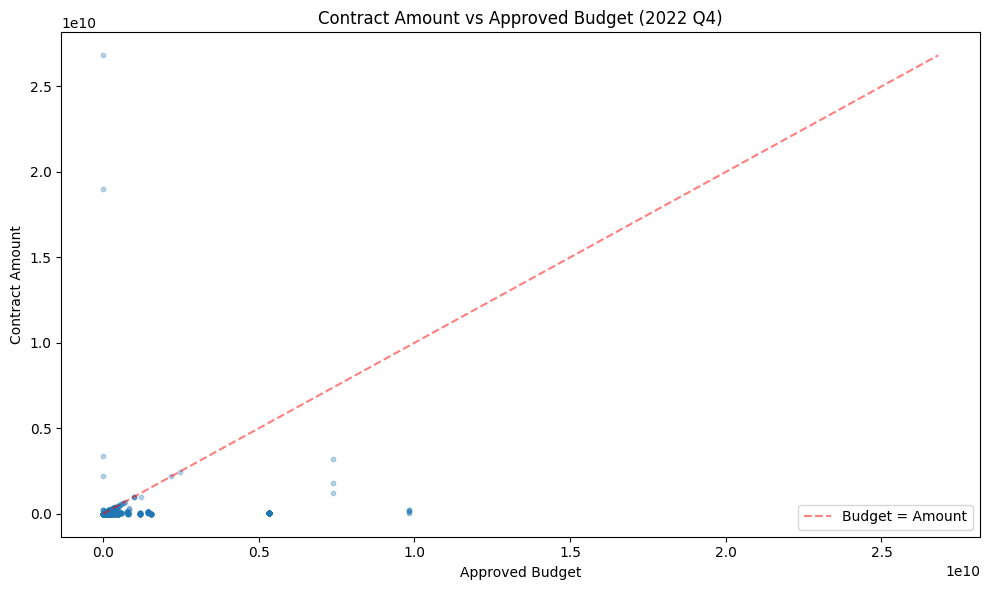

In [25]:
# Contract Amount vs Approved Budget
plt.figure(figsize=(10, 6))
plt.scatter(
    df_explore['Approved Budget of the Contract'], 
    df_explore['Contract Amount'],
    alpha=0.3, s=10
)
max_val = max(
    df_explore['Approved Budget of the Contract'].max(),
    df_explore['Contract Amount'].max()
)
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Budget = Amount')
plt.xlabel('Approved Budget')
plt.ylabel('Contract Amount')
plt.title('Contract Amount vs Approved Budget (2022 Q4)')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

**Key Findings:**
- 504,833 procurement records from 2022 Q4
- Same bid appears multiple times (different line items) - will deduplicate
- KEY columns available:
  - ✅ Procurement Mode (competitive vs negotiated)
  - ✅ Funding Instrument (GAA, corporate, local)
  - ✅ Awardee Organization (supplier tracking)
  - ✅ UNSPSC Code (standardized categories)
  - ✅ Contract Amount & Approved Budget
  - ✅ Geographic data (Region, Province)
  
**Anomaly indicators detected:**
- Price variances beyond ±50%
- Suspiciously short bidding periods
- Fast award decisions
- High-frequency contract winners

**Next:** Notebook 02 - Preprocessing & Feature Engineering